# Basic utils for Investing based on Indicators

## Imports

In [2]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
import plotly.express as px

# Attribution d'une graine.
random.seed(1)

torch.manual_seed(1)

%reload_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data reading and processing

In [3]:
pair = 'SOLUSDT'
timeframe = '5m'
type_data = 'Futures'

# Importation des données


data = pd.read_csv(f'../data/binance/{pair}_{timeframe}_{type_data}.csv', parse_dates=[0], index_col=0)
data

,Open,High,Low,Close,Volume,Qav,Trades,Taker_base_vol,Taker_quote_vol
Date,,,,,,,,,
2020-09-14 09:00:00,3.2002,4.9100,3.2002,3.3045,42698,1.426940e+05,640,15267,5.195271e+04
2020-09-14 09:05:00,3.3045,3.3974,3.2844,3.3497,51149,1.712361e+05,1152,28120,9.440854e+04
2020-09-14 09:10:00,3.3486,3.3576,3.3151,3.3393,23974,7.976511e+04,675,6843,2.276923e+04
2020-09-14 09:15:00,3.3443,3.4189,3.3353,3.3834,65640,2.223665e+05,1231,24917,8.447305e+04
2020-09-14 09:20:00,3.3855,3.4149,3.3709,3.3787,55165,1.865342e+05,825,11150,3.776340e+04
...,...,...,...,...,...,...,...,...,...
2024-09-04 19:35:00,133.0160,133.2070,132.5270,132.9030,173991,2.312146e+07,13635,64643,8.591545e+06
2024-09-04 19:40:00,132.9040,133.3170,132.7000,132.7360,72642,9.664593e+06,6799,36578,4.867733e+06
2024-09-04 19:45:00,132.7360,133.1360,132.7330,133.0310,43489,5.781083e+06,4668,24068,3.199412e+06


0.001651115573386692


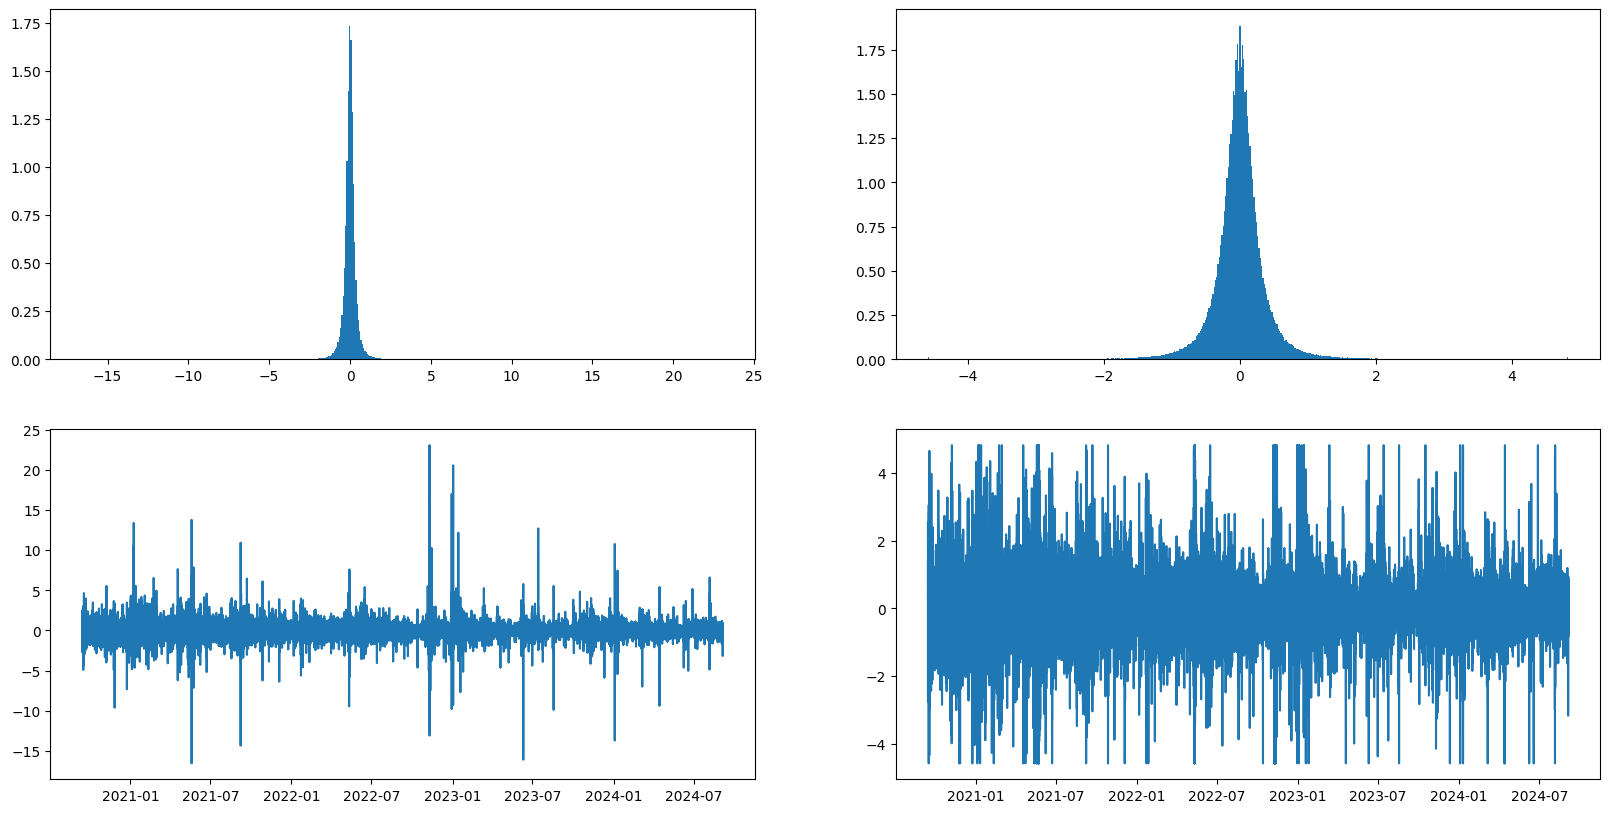

In [4]:
data.loc[:, '%R'] = data['Close'].pct_change()*100

df = data[['%R']].copy()

quatiles_threshold = 0.0002

plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)    
plt.hist(df['%R'] , bins=500, density=True)

plt.subplot(2, 2, 3)
plt.plot(df['%R'])

df['%R'] = df['%R'].clip(lower=df['%R'].quantile(quatiles_threshold), upper=df['%R'].quantile(1-quatiles_threshold))

print(df['%R'].mean())

# df['%R'] = df['%R'] - df['%R'].mean()

plt.subplot(2, 2, 2)
plt.hist(df['%R'], bins=500, density=True)

plt.subplot(2, 2, 4)
plt.plot(df['%R'])

plt.show()

In [5]:
import ta

df.dropna(inplace=True)

In [6]:
df.describe()

,%R
count,418019.000000
mean,0.001651
std,0.415585
min,-4.582954
25%,-0.165888
50%,0.000000
75%,0.166059
max,4.829074


In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

train_data, test_data = df[:int(len(data)*0.8)], df[int(len(data)*0.8):]

train_data = train_data.to_numpy()

test_data = test_data.to_numpy()

start_index = 0

train_target = train_data[:, :1]

test_target = test_data[:, :1]

for k in range(0, 2):
    train_target = train_target - train_target.mean()
    test_target = test_target - test_target.mean()
    
    print(f'k = {k}: train_target mean = {train_target.mean()}, test_target mean = {test_target.mean()}')

scaler = StandardScaler()


train_data = scaler.fit_transform(train_data[:, start_index:]) 
test_data = scaler.transform(test_data[:, start_index:])

k = 0: train_target mean = 7.054093951017693e-18, test_target mean = 2.5497030097966587e-18
k = 1: train_target mean = 4.334443271107257e-18, test_target mean = 2.5284554847150198e-18


In [8]:
def run_epoch(model, dataloader, optimizer, criterion, update_description=1):
    
    model.train()
    
    epoch_loss = 0

    batchs_number = len(dataloader)

    batchs = tqdm(enumerate(dataloader), unit='batch', total=batchs_number)
    for idx, (src, tgt_mask, tgt) in batchs:

        src = src.to(device)

        tgt = tgt.to(device)

        optimizer.zero_grad()

        inv, diff_inv = model(src, tgt_mask.to(device))

        loss = criterion(inv.contiguous(), diff_inv.contiguous(), tgt.contiguous())
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += (loss.detach().item())

        if (idx + update_description) % round(batchs_number/update_description) == 0:
            batchs.set_description('MSE {:.3E} '.format(
                epoch_loss/(idx+1)))

    return epoch_loss/batchs_number

In [9]:
def shift_sum(x):
    out = np.zeros((x.shape[0] + x.shape[1]-1))
    
    for k in range(x.shape[0]):
        out[k:k+x.shape[1]] += x[k]
        
    return out

In [10]:
torch2numpy = lambda x: x.cpu().detach().numpy()

def eval_epoch(model, dataloader, points=0):

    prediction = []
    targets = []
    returns = []
    
    with torch.no_grad():
        for idx, (src, tgt_mask, tgt) in enumerate(dataloader):
            
            pred = model.model(src.to(device))
            prediction.append(torch2numpy(pred[...,0]))
            targets.append(torch2numpy(tgt[...,0]))


    prediction = np.concatenate(prediction, axis=0)
    targets = np.concatenate(targets, axis=0)
    
    # prediction = shift_sum(prediction)/prediction.shape[1]
    # targets = shift_sum(targets)/targets.shape[1]
    
    returns = prediction * targets
    
    norm = np.abs(np.diff(prediction, axis=0)).mean()
    normed_returns = returns/norm
    
    portfolio = np.cumsum(normed_returns)
    

    if points > 0:
        
        plt.figure(figsize=(14, 7))
        plt.subplot(2, 1, 1)
        plt.plot(targets[-points:], label='True')
        plt.plot(prediction[-points:], label='Prediction')
        plt.legend()
        plt.subplot(2, 1, 2)
        plt.plot(returns[-points:], label='Returns')
        plt.legend()
        plt.figure(figsize=(14, 7))
        plt.plot(portfolio, label='Portfolio')
        plt.show()

    return  normed_returns.mean(), norm, returns.mean()

In [11]:
class NN(nn.Module):
    def __init__(self, config):
        super(NN, self).__init__()
        self.input_size = config['input_size']
        self.pred_len = config['pred_len']
        self.hidden_size = config['hidden_size']
        
        self.linear1 = nn.Linear(self.input_size, self.hidden_size)
        self.linear2 = nn.Linear(self.hidden_size, self.hidden_size)
        self.linear3 = nn.Linear(self.hidden_size, self.pred_len)
        self.activation = nn.ReLU() #nn.Tanh()
        self.tanh = nn.Tanh()
        
        
    def forward(self, x, tgt_mask):
        
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear3(x)

        return self.tanh(x)

In [12]:
from torch.utils.data import Dataset
import numpy as np


class TimeSeriesDataset(Dataset):
    def __init__(self, data, tgt, seq_len, pred_len, offset=0):
        
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.offset = offset

        if tgt is not None:
            assert tgt.shape[0] == data.shape[0]
            
            tgt = tgt.astype(np.float32)
            
        
        self.src, self.tgt = self.prepare_data(data, 
                                               seq_len, pred_len, offset, tgt)
        
        self.src = self.src.astype(np.float32)
        self.tgt = self.tgt.astype(np.float32)

    def __len__(self):
        return len(self.src)-1

    def __getitem__(self, idx):
        return (self.src[idx+1], self.src[idx], self.tgt[idx+1])
        # return (self.src[idx], torch.zeros([1,1]), self.tgt[idx])

    def prepare_data(self, data, seq_len, pred_len, offset=0, tgt=None):
        """
        Prepare data for training and testing.
        """

        sequences = np.lib.stride_tricks.sliding_window_view(
            data[:-pred_len-offset], (seq_len, data.shape[1])).squeeze(1)


        if tgt is None:
            targets = np.lib.stride_tricks.sliding_window_view(
                    data[seq_len + offset:, 0], (pred_len,))
        else:
            targets = np.lib.stride_tricks.sliding_window_view(
                    tgt[seq_len + offset:, 0], (pred_len,))
        return sequences, targets

In [13]:
class ExpInvestLoss(nn.Module):
    def __init__(self, alpha=0.1):
        super(ExpInvestLoss, self).__init__()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        
        return torch.exp(-y_true*y_pred*self.alpha).mean()
    
class InvestLoss(nn.Module):
    def __init__(self, alpha=0):
        super(InvestLoss, self).__init__()
        self.alpha = alpha
    def forward(self, y_pred, y_true):
        
        r = y_true*y_pred
        
        return -r.mean()
    
class DiffInvestLoss(nn.Module):
    def __init__(self, fee=0.04):
        super(DiffInvestLoss, self).__init__()
        self.fee = fee
    def forward(self, inv, diff_inv, returns):
        
        if not self.fee == 0:
            return -((inv*returns).mean() - self.fee * diff_inv.abs().mean())

        else:
            return -(inv*returns).mean()

In [62]:
config = {
    # data
 'seq_len': 1,
 'pred_len': 1,
 'batch_size': train_data.shape[0]//1000,
 'shuffle': True,
 'output_size': train_data.shape[1],
 'offset': 0,
 
    # model

 'model': NN,
 'input_size': train_data.shape[1],
 
 'hidden_size': 64,
 'num_layers': 2,
 'dropout': 0.0,
 'bidirectional': False,
 
 # Training
 
  'num_epochs': 10,
 'lr': 1e-1,
 'max_grad_norm': 0.1,
 'gamma': 0.2,
 'patience': 10,
 'cd': 0,
 }

class AttrDict(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

config = AttrDict(config)

In [63]:

from torch.utils.data import DataLoader

train_dataset = TimeSeriesDataset(train_data, tgt=train_target, seq_len=config.seq_len, pred_len=config.pred_len, offset=config.offset)

train_dataloader = DataLoader(
    train_dataset, config.batch_size, shuffle=config.shuffle, pin_memory=False)

train_dataloader_infer = DataLoader(
    train_dataset, config.batch_size, shuffle=False)

val_dataset = TimeSeriesDataset(test_data, tgt=test_target, seq_len=config.seq_len, pred_len=config.pred_len, offset=config.offset)

val_dataloader = DataLoader(val_dataset, config.batch_size, shuffle=False)

In [76]:
import torch.nn as nn


class Env(nn.Module):
    def __init__(self, model, config):
        super(Env, self).__init__()
        self.model = model(config)

        
    def forward(self, x, x_prev):
        
        x = self.model(x)
        
        x_prev = self.model(x_prev)

        return x, x-x_prev

class NN(nn.Module):
    def __init__(self, config):
        super(NN, self).__init__()
        self.input_size = config.input_size
        self.pred_len = config.pred_len
        self.hidden_size = config.hidden_size
        
        self.linear1 = nn.Linear(self.input_size, self.pred_len)
        self.activation = nn.ReLU() #nn.Tanh()
        self.tanh = nn.Tanh()
        
    def forward(self, x):
        
        x = self.linear1(x)
        
        x = self.tanh(x)

        return x.squeeze(-1)
    

model = Env(NN, config).to(device)


criterion = DiffInvestLoss(0.04)

optimizer = torch.optim.Adam(model.parameters(), 1e0, amsgrad=True, weight_decay=1e-5)
# optimizer = torch.optim.SGD(model.parameters(), 100)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.9)

train_history = []
val_history = []

a = []
b = []

In [77]:
train_t = torch.tensor(train_data[:-1], dtype=torch.float32).to(device).squeeze()
returns = torch.tensor(train_target[1:], dtype=torch.float32).to(device).squeeze()

def ev(a,b, data):
    return torch.tanh(a*data + b)

tl = torch.linspace(-25, 0, 101).to(device)
tl2 = torch.linspace(-50, 50, 101).to(device).flip(0)

def torch_grid(l1, l2):
    
    grid = np.zeros((l1.shape[0], l2.shape[0]), dtype=np.float32)
    
    for i, x in enumerate(l1):
        for j, y in enumerate(l2):
            grid[j, i] = -criterion(ev(x, y, train_t), ev(x, y, train_t).diff(), returns).cpu().detach().numpy()
    
    return grid


In [78]:
epoch = tqdm(range(50), unit='epoch')

for e in epoch:
    model.train()
    
    loss = run_epoch(model, train_dataloader, optimizer, criterion, 1)
    
    scheduler.step()
    
    print(scheduler.get_last_lr(), model.model.linear1.weight[0].item(), model.model.linear1.bias[0].item())
    
    train_history.append(loss)
    
    a.append(model.model.linear1.weight[0].item())
    b.append(model.model.linear1.bias[0].item())
    
    # model.eval()
    
    # val_loss = eval_epoch(model, val_dataloader, points=0)
    
    # val_history.append(-val_loss[0])

  0%|          | 0/50 [00:00<?, ?epoch/s]

  0%|          | 0/1002 [00:00<?, ?batch/s]

[1.0] -0.0005712321726605296 4.912569522857666


  0%|          | 0/1002 [00:00<?, ?batch/s]

[1.0] -0.8137261867523193 10.358999252319336


...

[1.0] 0.02049441635608673 14.729947090148926


  0%|          | 0/1002 [00:00<?, ?batch/s]

[1.0] 0.054388031363487244 3.171302080154419


  0%|          | 0/1002 [00:00<?, ?batch/s]

KeyboardInterrupt: 

<Axes: >

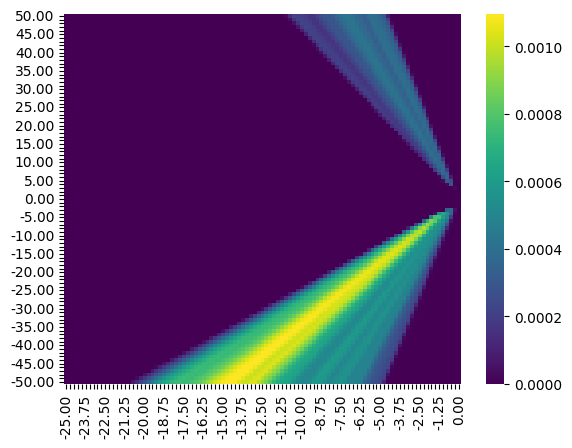

In [37]:
import seaborn as sns

def get_ticklabels(l, space=5):
    return [f'{l[x]:.2f}' if x%space ==0 else '' for x in range(101)]

sns.heatmap(torch_grid(tl, tl2).clip(0), xticklabels=get_ticklabels(tl), yticklabels=get_ticklabels(tl2), cmap='viridis')

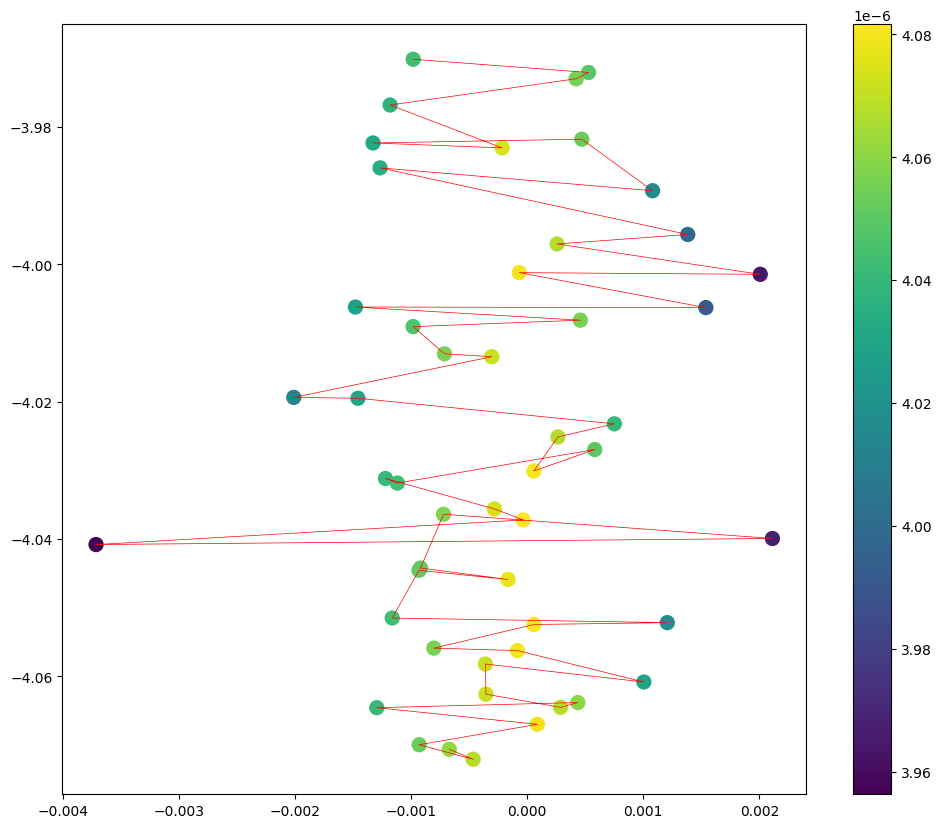

In [66]:
evs = [ev(x , y, train_t) for x, y in zip(a, b)]

s = np.array([-criterion(e, e.diff(), returns).item() for e in evs]).clip(0)


plt.figure(figsize=(12, 10))
plt.plot(a, b, '-', lw=0.5, c='r')
plt.scatter(a, b, c=s, cmap='viridis', s=100)
plt.colorbar()

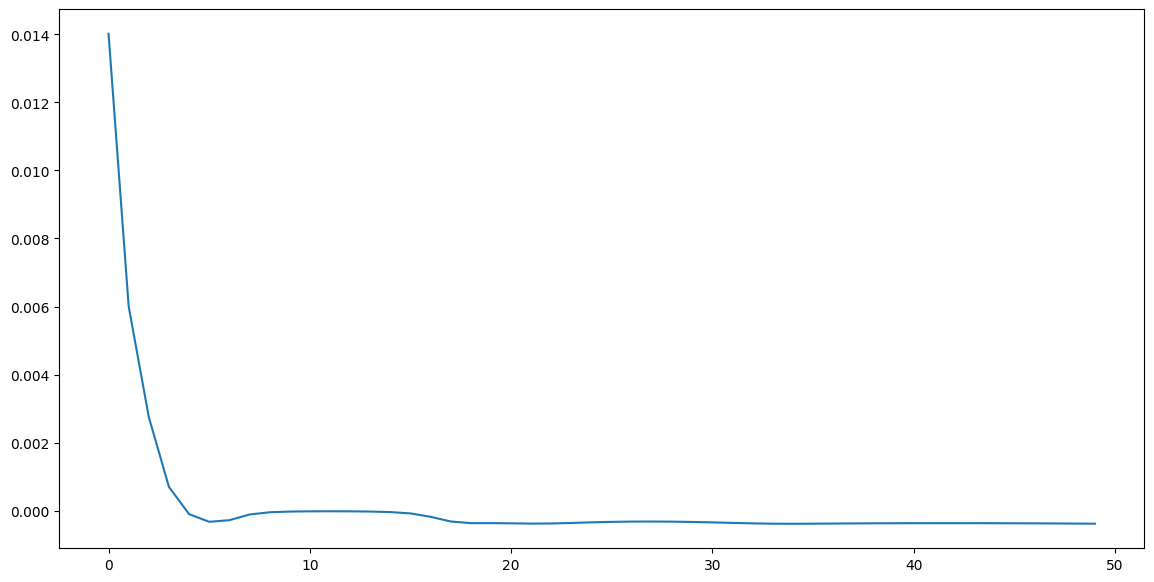

In [47]:
plt.figure(figsize=(14, 7))

# plt.subplot(2, 1, 1)
plt.plot(train_history, label='Train')

# plt.subplot(2, 1, 2)
# plt.plot(val_history, label='Val')

In [ ]:
print(model.model.linear1.weight, model.model.linear1.bias)

Parameter containing:
tensor([[-39.9651]], requires_grad=True) Parameter containing:
tensor([-7.7493], requires_grad=True)


In [ ]:
train_t = torch.tensor(train_data[:-1], dtype=torch.float32).to(device).squeeze()
returns = torch.tensor(train_target[1:], dtype=torch.float32).to(device).squeeze()

def ev(a,b, data):
    return torch.tanh(a*data + b)

tl = torch.linspace(-25, 0, 101).to(device)
tl2 = torch.linspace(-50, 50, 101).to(device).flip(0)

def torch_grid(l1, l2):
    
    grid = np.zeros((l1.shape[0], l2.shape[0]), dtype=np.float32)
    
    for i, x in enumerate(l1):
        for j, y in enumerate(l2):
            grid[j, i] = -criterion(ev(x, y, train_t), ev(x, y, train_t).diff(), returns).cpu().detach().numpy()
    
    return grid


tensor(4.1635e-06, grad_fn=<NegBackward0>)

In [ ]:
import seaborn as sns

def m1(inv, tgt):
    return (inv*tgt).mean()/(np.abs(np.diff(inv)).mean()+1e-5)

l = np.linspace(-50, 50, 101)

l2 = np.linspace(-50, 50, 101)[::-1]


def grid_ab(dt, tgt, metric=m1):
    total_score = []

    for j in l2:

        score = []

        for i in l:
            
            inv = np.tanh(dt * i + j)
            
            # inv = inv - inv.mean()

            score.append(metric(inv, tgt))
        
        total_score.append(score)
        
    return np.array(total_score) 

def get_ticklabels(l, space=5):
    return [f'{l[x]:.2f}' if x%space ==0 else '' for x in range(101)]

In [ ]:
mmean = lambda inv, tgt: (inv*tgt).mean()

train_gmean = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=mmean)
test_gmean = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=mmean)

minv = lambda inv, tgt: np.abs(np.diff(inv)).mean()

train_ginv = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=minv)
test_ginv = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=minv)

mstd = lambda inv, tgt: (inv*tgt).std()

train_gstd = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=mstd)
test_gstd = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=mstd)


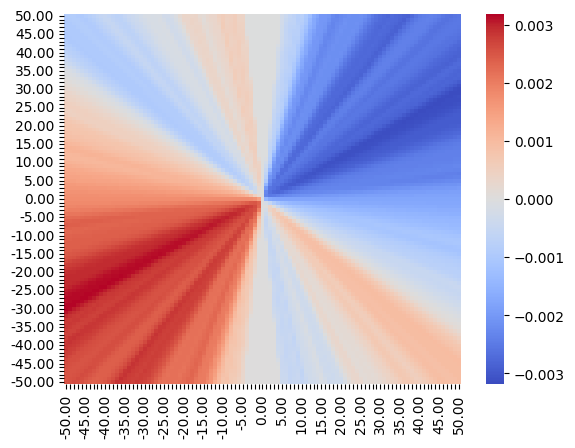

<Axes: >

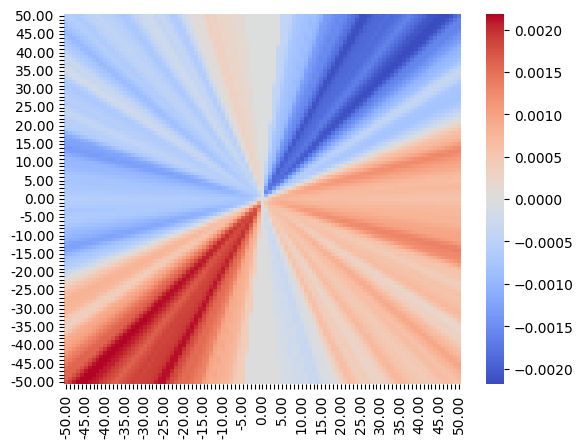

In [ ]:
sns.heatmap(train_gmean, cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
plt.show()
sns.heatmap(test_gmean, cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))

/tmp/ipykernel_11677/1524795153.py:5: RuntimeWarning: divide by zero encountered in log
  sns.heatmap(np.log(train_gmean-fee*train_ginv), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
/tmp/ipykernel_11677/1524795153.py:5: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(train_gmean-fee*train_ginv), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
/tmp/ipykernel_11677/1524795153.py:7: RuntimeWarning: divide by zero encountered in log
  sns.heatmap(np.log(test_gmean-fee*test_ginv), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
/tmp/ipykernel_11677/1524795153.py:7: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(test_gmean-fee*test_ginv), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))


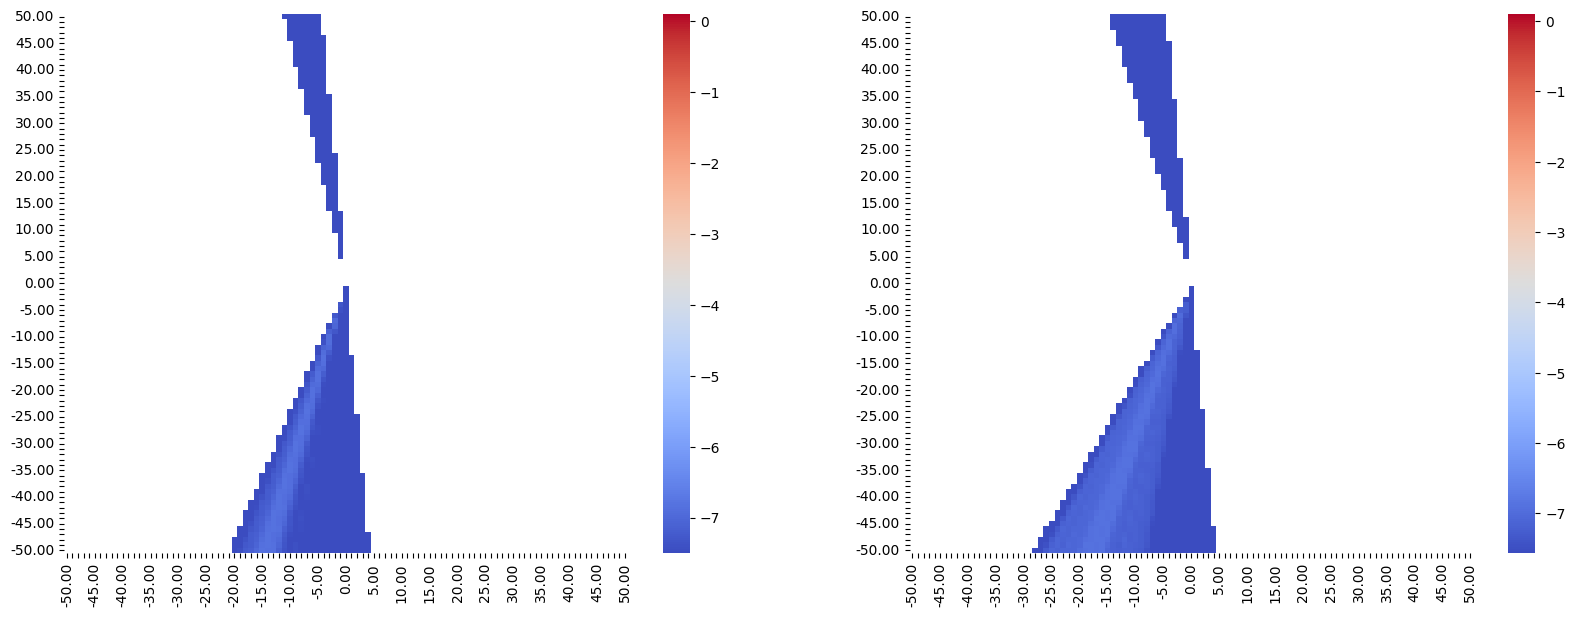

In [ ]:
fee = 0.04

plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
sns.heatmap(np.log(train_gmean-fee*train_ginv), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
plt.subplot(1, 2, 2)
sns.heatmap(np.log(test_gmean-fee*test_ginv), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
plt.show()


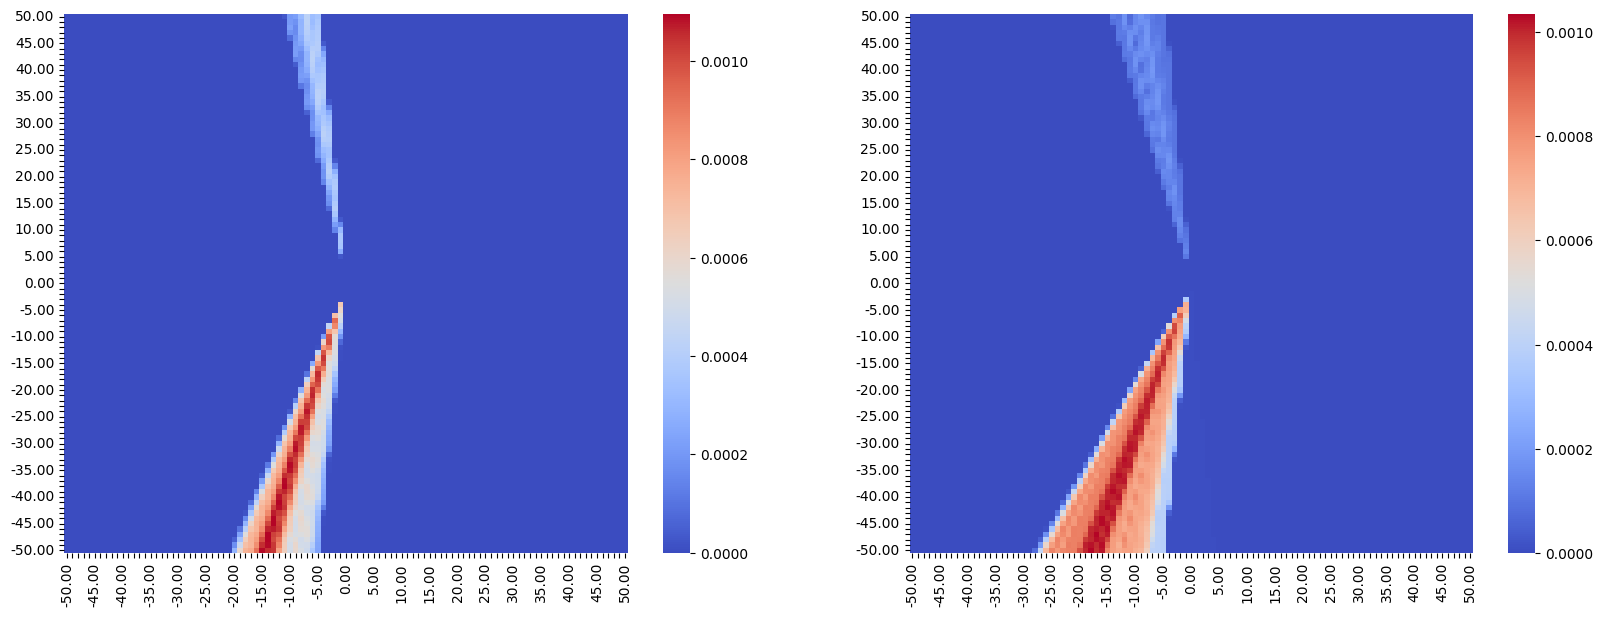

In [ ]:
fee = 0.04

plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
sns.heatmap((train_gmean-fee*train_ginv).clip(0), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
plt.subplot(1, 2, 2)
sns.heatmap((test_gmean-fee*test_ginv).clip(0), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
plt.show()

<Axes: >

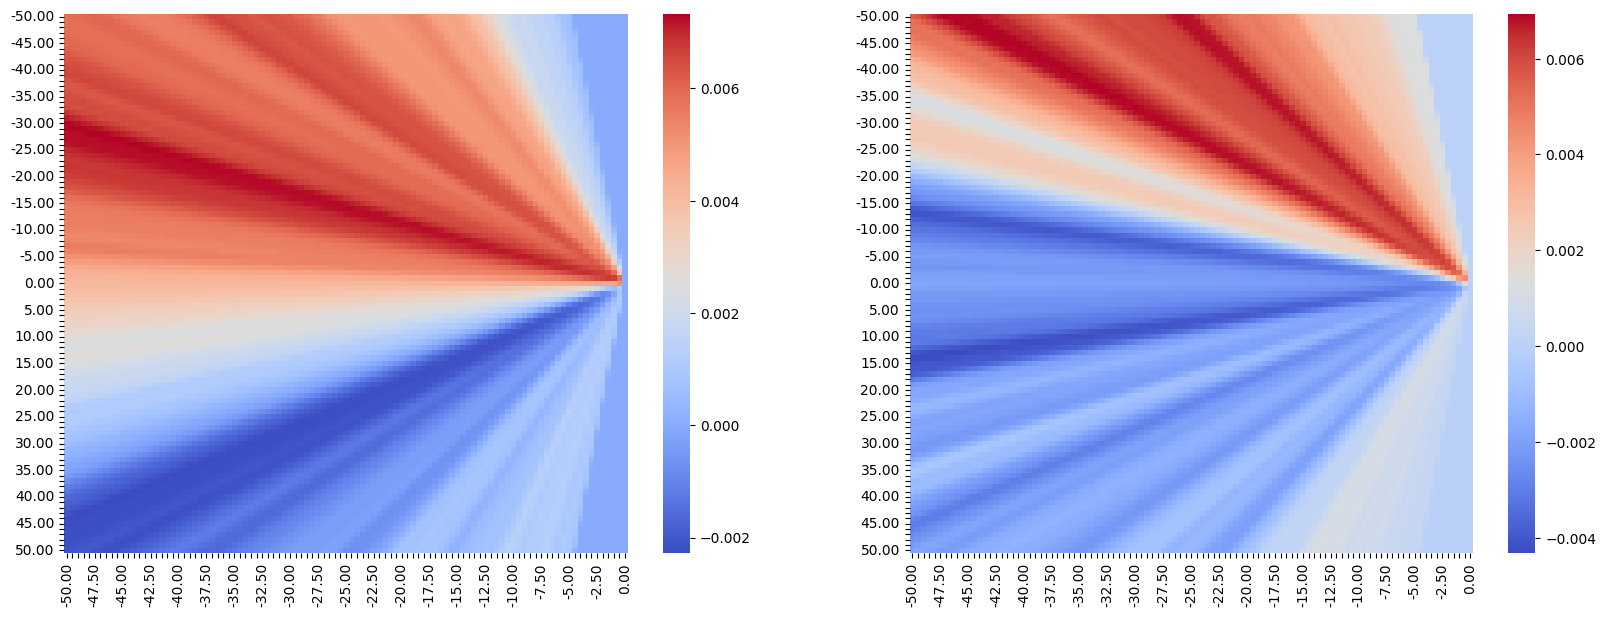

In [ ]:
eps = 1e-5

plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
sns.heatmap(train_gmean/(train_gstd+eps), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2))
plt.subplot(1, 2, 2)
sns.heatmap(test_gmean/(test_gstd+eps), cmap='coolwarm', xticklabels=get_ticklabels(l), yticklabels=get_ticklabels(l2)) 

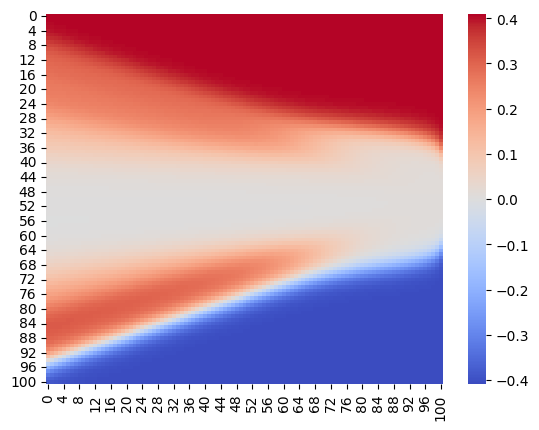

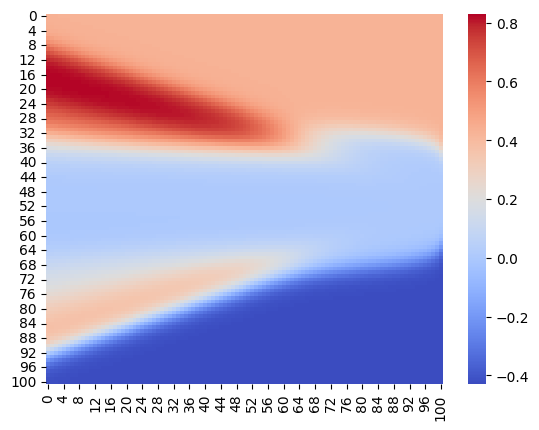

<Axes: >

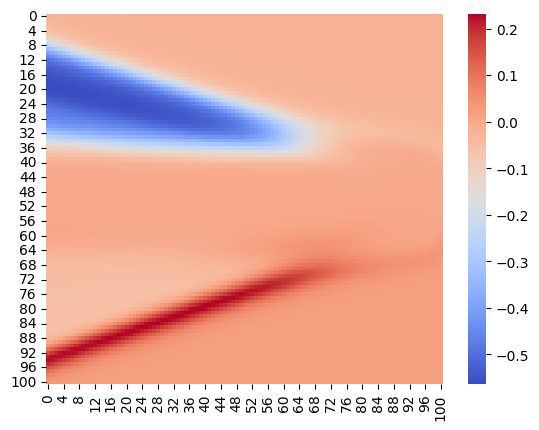

In [ ]:
train_grid = grid_ab(train_data[:-1, 0], train_target[1:, 0])
test_grid = grid_ab(test_data[:-1, 0], test_target[1:, 0])

sns.heatmap(train_grid, cmap='coolwarm')
plt.show()

sns.heatmap(test_grid, cmap='coolwarm')
plt.show()

sns.heatmap(train_grid - test_grid, cmap='coolwarm')


/tmp/ipykernel_115388/3021797617.py:9: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(train_grid), cmap='coolwarm')


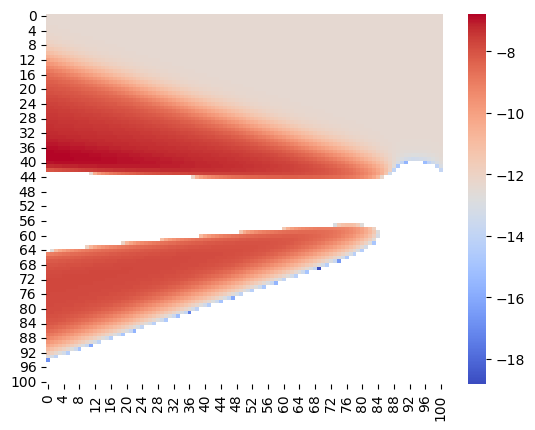

/tmp/ipykernel_115388/3021797617.py:12: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(test_grid), cmap='coolwarm')


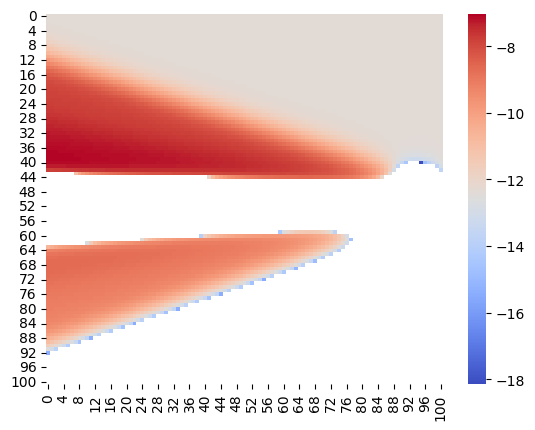

In [ ]:

def m2(inv, tgt):
    return (inv*tgt).mean()-0.02*(np.abs(np.diff(inv)).mean())



train_grid = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=m2)
test_grid = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=m2)

sns.heatmap(np.log(train_grid), cmap='coolwarm')
plt.show()

sns.heatmap(np.log(test_grid), cmap='coolwarm')
plt.show()


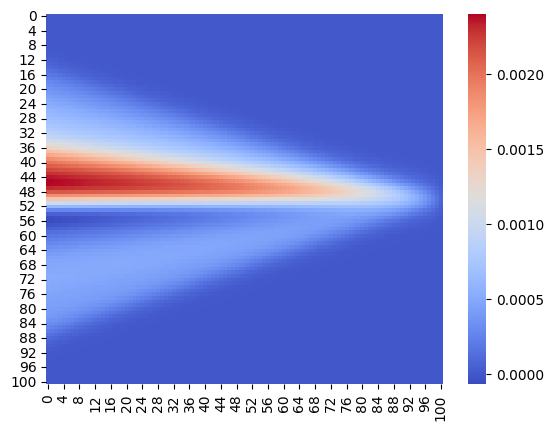

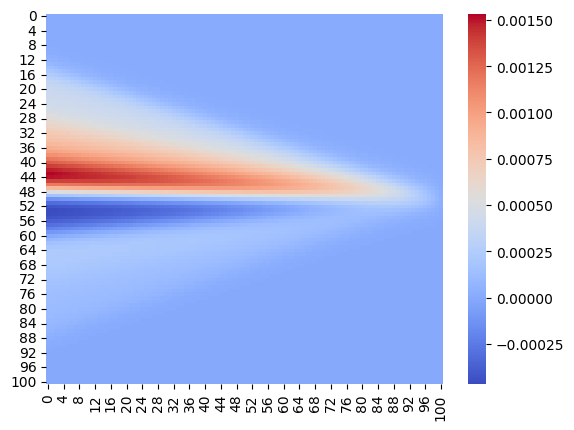

In [ ]:

m3 = lambda inv, tgt: (inv*tgt).mean()

train_grid = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=m3)
test_grid = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=m3)

sns.heatmap(train_grid, cmap='coolwarm')
plt.show()
sns.heatmap(test_grid, cmap='coolwarm')
plt.show()


In [ ]:
bias = l2[np.argmax(test_grid, keepdims=True)//101]
weights =l[np.argmax(test_grid, keepdims=True)%101] 
weights, bias

(array([[-1.]]), array([[-2.1]]))

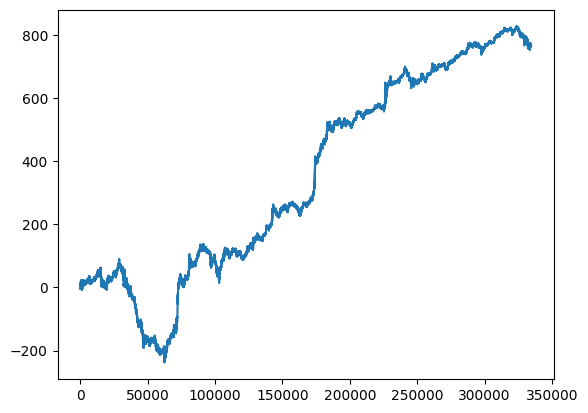

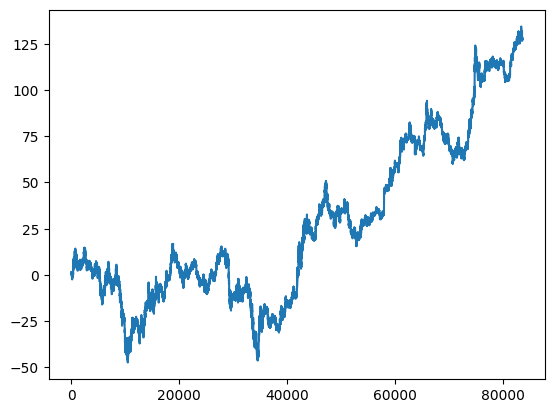

In [ ]:
train_r = np.tanh(train_data[:-1, 0]*weights + bias)*train_target[1:, 0]
test_r = np.tanh(test_data[:-1, 0]*weights + bias)*test_target[1:, 0]
plt.plot(np.cumsum(train_r.squeeze()))
plt.show()

plt.plot(np.cumsum(test_r.squeeze()))
plt.show()

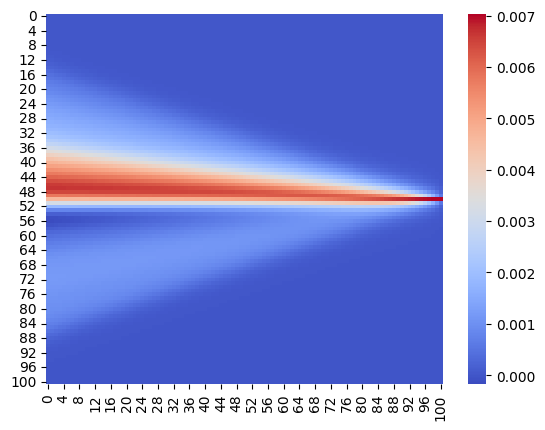

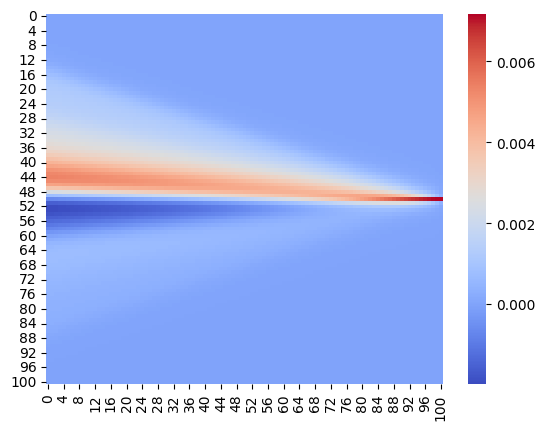

In [ ]:
def m4(inv, tgt):
    r = inv*tgt
    return r.mean()/r.std()

train_grid = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=m4)
test_grid = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=m4)

sns.heatmap(train_grid, cmap='coolwarm')
plt.show()


sns.heatmap(test_grid, cmap='coolwarm')
plt.show()

In [ ]:
bias = l2[np.argmax(test_grid, keepdims=True)//101]
weights =l[np.argmax(test_grid, keepdims=True)%101 ] 
weights, bias

(array([[-0.01]]), array([[0.]]))

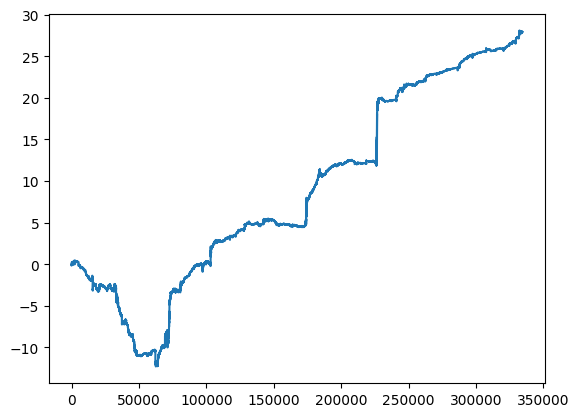

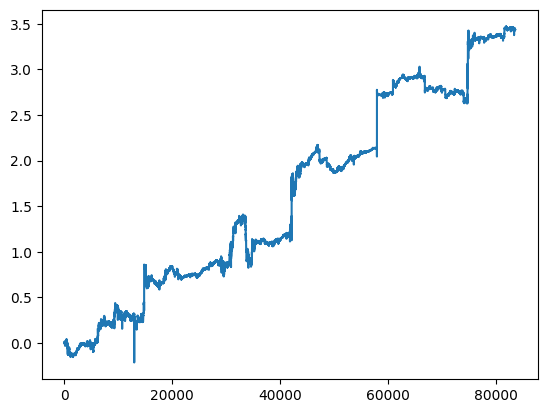

In [ ]:
train_r = np.tanh(train_data[:-1, 0]*weights + bias)*train_target[1:, 0]
test_r = np.tanh(test_data[:-1, 0]*weights + bias)*test_target[1:, 0]
plt.plot(np.cumsum(train_r.squeeze()))
plt.show()
plt.plot(np.cumsum(test_r.squeeze()))

/tmp/ipykernel_115388/2034469631.py:9: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(train_grid), cmap='coolwarm')


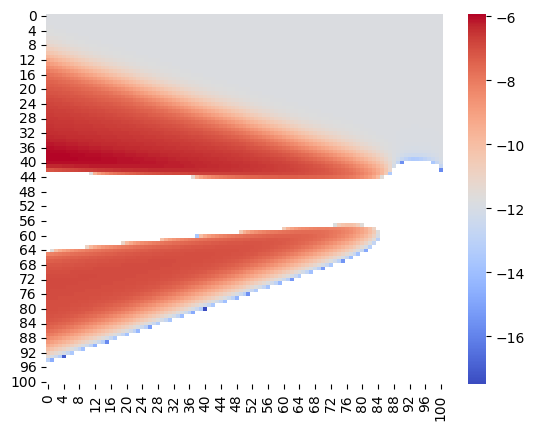

/tmp/ipykernel_115388/2034469631.py:13: RuntimeWarning: invalid value encountered in log
  sns.heatmap(np.log(test_grid), cmap='coolwarm')


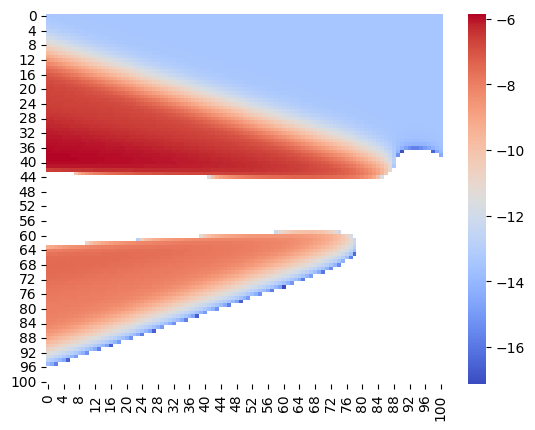

In [ ]:
def m5(inv, tgt):
    r = inv*tgt
    ar = (r[1:]-0.02*np.abs(np.diff(inv)))
    return ar.mean()/ar.std()

train_grid = grid_ab(train_data[:-1, 0], train_target[1:, 0], metric=m5)
test_grid = grid_ab(test_data[:-1, 0], test_target[1:, 0], metric=m5)

sns.heatmap(np.log(train_grid), cmap='coolwarm')
plt.show()


sns.heatmap(np.log(test_grid), cmap='coolwarm')
plt.show()

5.618632954070169e-18


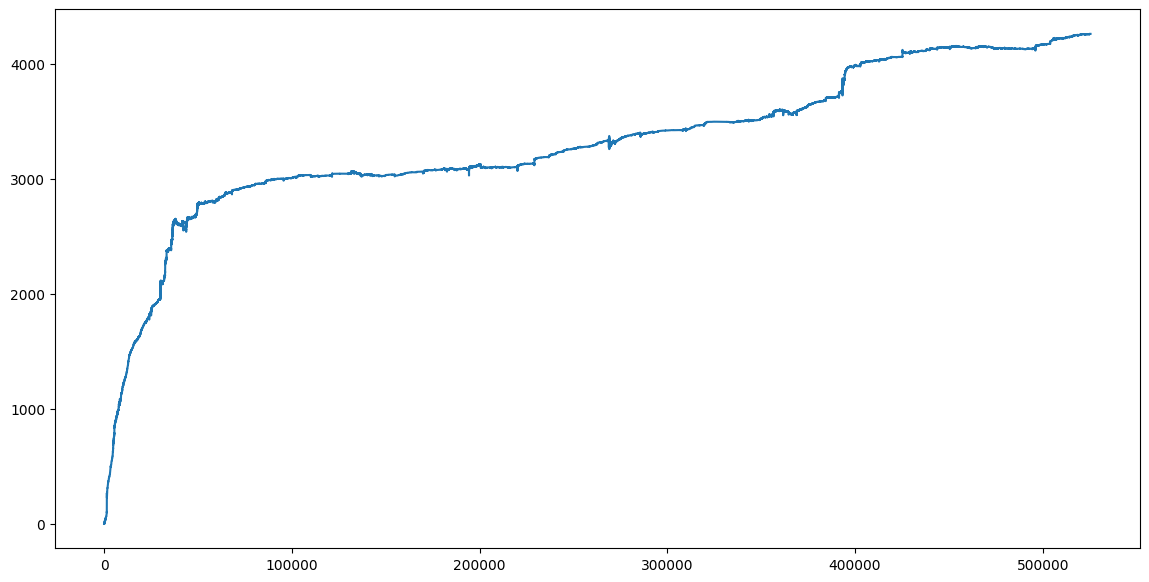

In [ ]:
r = (train_data[:-1] * -0.5)* train_target[1:]


print(train_target.mean())

rcm = np.cumsum(r)

plt.figure(figsize=(14, 7))
plt.plot(rcm)

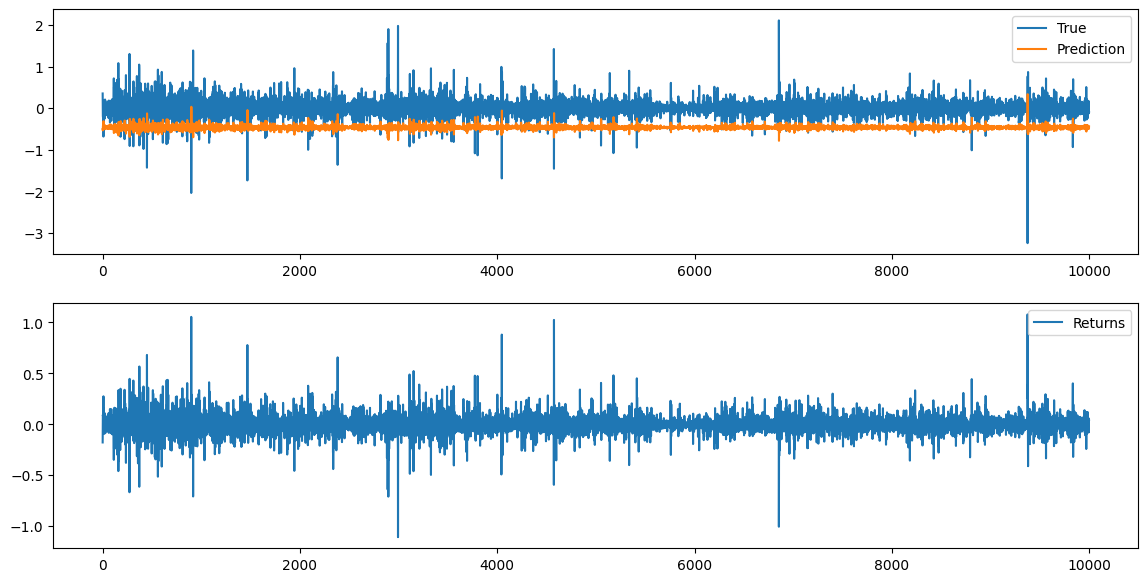

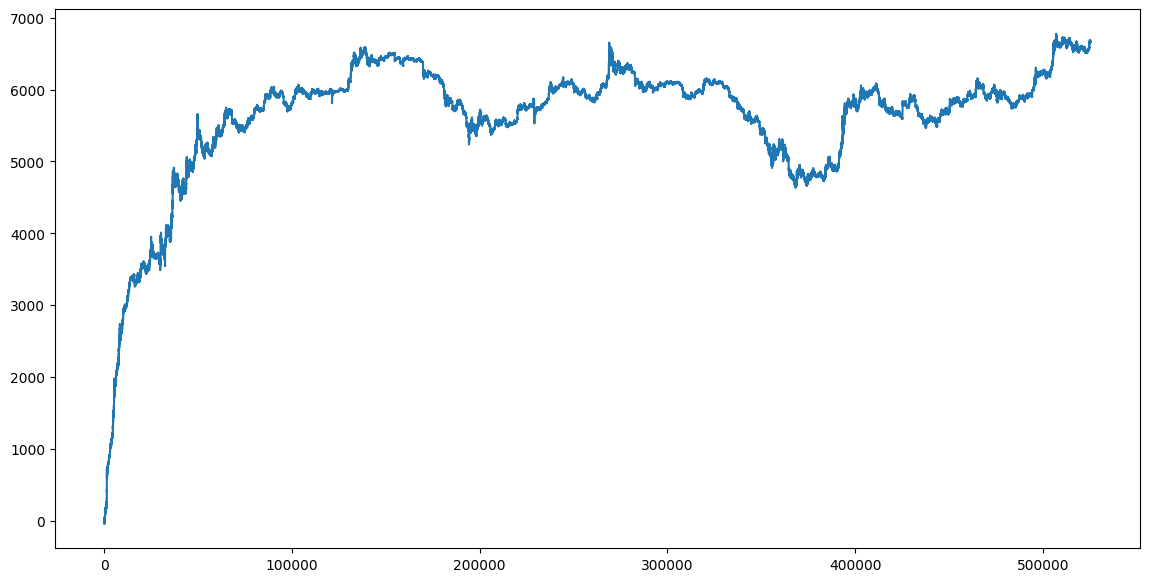

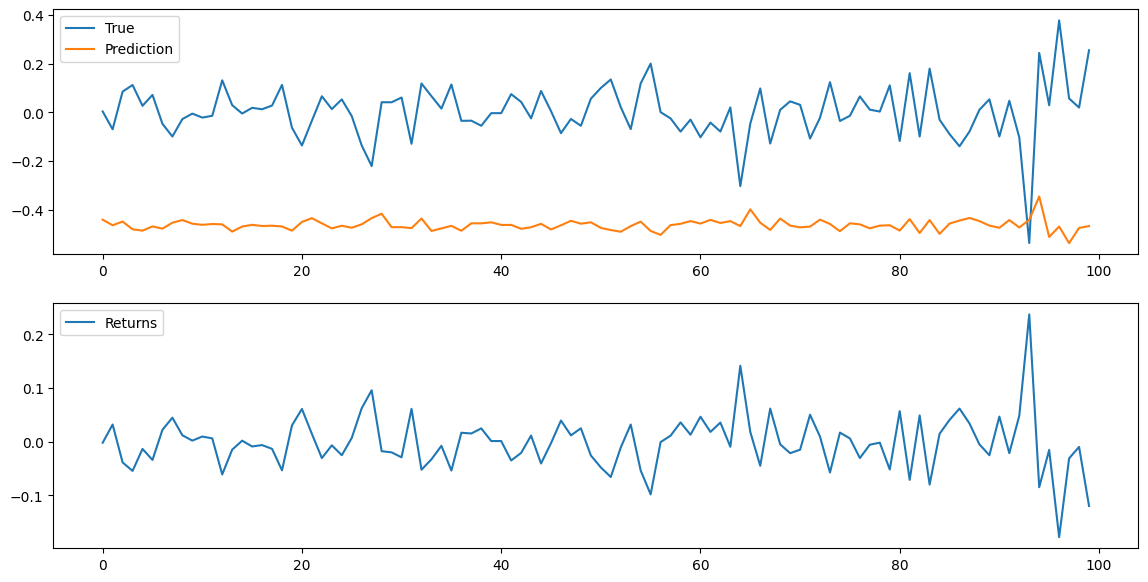

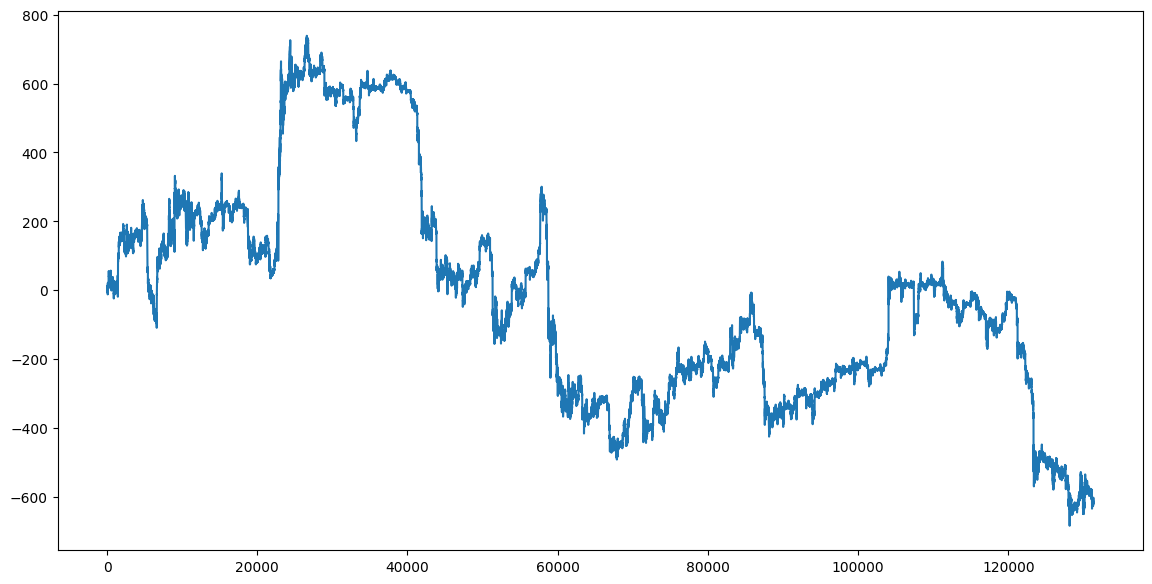

##### TRAIN mse 1.2673E-02 mae 5.0000E-02 r: 6.3365E-04 VALIDATION mse -4.7243E-03 mae 2.5029E-02 r: -1.1824E-04 #####


In [ ]:

print('##### TRAIN mse {:.4E} mae {:.4E} r: {:.4E} VALIDATION mse {:.4E} mae {:.4E} r: {:.4E} #####'.format(*eval_epoch(model, train_dataloader_infer, points=10000), *eval_epoch(model, val_dataloader, points=100)))
